# О проекте

# Выбор локации для скважины

**Описание проекта**

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 10 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

**Цель проекта**

Решить, где бурить новую скважину.

**План-инструкция проекта**

1. Загрузить и подготовьте данные. Пояснить порядок действий.
2. Обучить и проверьте модель для каждого региона:
     - 2.1. Разбить данные на обучающую и валидационную выборки в соотношении 75:25.
     - 2.2. Обучить модель и сделать предсказания на валидационной выборке.
     - 2.3. Сохранить предсказания и правильные ответы на валидационной выборке.
     - 2.4. Напечатать на экране средний запас предсказанного сырья и RMSE модели.
     - 2.5. Проанализировать результаты.
3. Подготовиться к расчёту прибыли:
     - 3.1. Все ключевые значения для расчётов сохранить в отдельных переменных.
     - 3.2. Рассчитать достаточный объём сырья для безубыточной разработки новой скважины. Сравнить полученный объём сырья со средним запасом в каждом регионе.
     - 3.3. Написать выводы по этапу подготовки расчёта прибыли.
4. Напишите функцию для расчёта прибыли по выбранным скважинам и предсказаниям модели:
     - 4.1. Выбрать скважины с максимальными значениями предсказаний.
     - 4.2. Просуммировать целевое значение объёма сырья, соответствующее этим предсказаниям.
     - 4.3. Рассчитать прибыль для полученного объёма сырья.
5. Посчитайте риски и прибыль для каждого региона:
     - 5.1. Применить технику Bootstrap с 1000 выборок, чтобы найти распределение прибыли.
     - 5.2. Найти среднюю прибыль, 95%-й доверительный интервал и риск убытков. Убыток — это отрицательная прибыль.
     - 5.3. Написать выводы: предложить регион для разработки скважин и обосновать выбор.

**Описание данных**

Данные геологоразведки трёх регионов находятся в файлах:

- `'/datasets/geo_data_0.csv'`
- `'/datasets/geo_data_1.csv'`
- `'/datasets/geo_data_2.csv'`

где:
    
- `'id'` — уникальный идентификатор скважины;
- `'f0'`, `'f1'`, `'f2'` — три признака точек (неважно, что они означают, но сами признаки значимы);
- `'product'` — объём запасов в скважине (тыс. баррелей).

**Условия задачи:**

- Для обучения модели подходит только линейная регрессия (остальные — недостаточно предсказуемые).
- При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки.
- Бюджет на разработку скважин в регионе — 10 млрд рублей.
- При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс. рублей, поскольку объём указан в тысячах баррелей.
- После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.

## Загрузка и подготовка данных

### Подключение библиотек

Прежде, чем приступать к работе, необходимо подключить необходимые для этого библиотеки.

Так как исследовательский анализ проводить не требуется, данный спиок будет короче, чем обычно.

In [ ]:
# обновляем устаревшие библиотеки и загружаем недостающие
# "выключаем звук" (строчки с текстом по мере загрузки) с помощью -q
!pip install scikit-learn==1.5.2 -q # обновление для корректной работы некоторых частей кода
#!pip install optuna -q # байесовская оптимизация перебора гиперпараметров, не пригодились в данном проекте
#!pip install optuna-integration[sklearn] -q # байесовская оптимизация перебора гиперпараметров, дополнение к ней
!pip install --upgrade matplotlib -q
!pip install --upgrade seaborn -q

In [ ]:
# подключаем библиотеки
import pandas as pd
import numpy as np
import random # для одного из варианот выборки из выборки

# байесовская оптимизация перебора гиперпараметров, взяла целиком, так как отдельные элементы давали ошибки
# при sklearn 1.1.3, и при 1.5.2
#import optuna

# "выключаем" красные предупреждения, не пригодилось
# Лучше включать после того, как все сделано, чтобы для себя обращать внимание и что-то не проворонить,
# а также понимать - тот же перебор параметров по сетке еще думает и перебирает или уже завис намертво
import warnings

import seaborn as sns # для некоторых графиков и матриц
import matplotlib.pyplot as plt # для некоторых графиков

# подготовка данных
from sklearn.model_selection import train_test_split # для разбивки на выборки для МО
from sklearn.preprocessing import(
    StandardScaler, MinMaxScaler, RobustScaler
) # масштабирование количественных
#from sklearn.impute import SimpleImputer # работа с пропусками при кодировании, в нашей задаче не пригодилось

# инструменты для работы с пайплайнами
from sklearn.pipeline import Pipeline # пайплайны
from sklearn.compose import ColumnTransformer # помогает работать с данными разного типа в одном наборе

# модели
from sklearn.linear_model import LinearRegression # модель линейной регресии

# автоподбор параметров моделей, в нашей задаче не пригодилось, но в тех разделе осталось
#from optuna.integration import OptunaSearchCV # иногда выдает ошибку
#from optuna import distributions # для настройки гиперпараметров Optuna

#кросс-валидация
from sklearn.model_selection import KFold # создание блоков
from sklearn.model_selection import cross_val_score # оценка модели на кросс-валидации

# метрики моделей
from sklearn.metrics import mean_squared_error

In [ ]:
# задаем константы
RANDOM_STATE = 42
TEST_SIZE = 0.25
state = np.random.RandomState(12345)


<div class="alert alert-block alert-success">
<b>Успех:</b> Импорты и настройки на месте
</div>


Теперь, после того, как все необходимые библиотеки подключены, можно приступать к решению задач.

### Загрузка данных

Для данной задачи мы получили три датасета. Для начала загрузим их и посмотрим на содержимое.

Пусть использование цифр в имени датасета противоречит правилам хорошего тона, однако будет удобнее (и меньше шансов на путаницу), когда название датасетов совпадают с файлами, на основе которых они созданы (а в данном случае они используют цифры в своем имени). Также, для сохрания приемственности, будем использовать те же цифры для выборок, созданных на основе указанных датасетов.

In [ ]:
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
# загрузка нулевого датасета
try:
    geo_data_0 = pd.read_csv('/datasets/geo_data_0.csv')
except:
    geo_data_0 = pd.read_csv('https://адрес_удален/datasets/geo_data_0.csv')

In [ ]:
geo_data_0.head(20) # содержимое

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647
5,wX4Hy,0.969570,0.489775,-0.735383,64.741541
6,tL6pL,0.645075,0.530656,1.780266,49.055285
7,BYPU6,-0.400648,0.808337,-5.624670,72.943292
8,j9Oui,0.643105,-0.551583,2.372141,113.356160
9,OLuZU,2.173381,0.563698,9.441852,127.910945


In [ ]:
geo_data_0.shape # размер

(100000, 5)

In [ ]:
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
# загрузка первого датасета
try:
    geo_data_1 = pd.read_csv('/datasets/geo_data_1.csv')
except:
    geo_data_1 = pd.read_csv('https://адрес_удален/datasets/geo_data_1.csv')

In [ ]:
geo_data_1.head(20) # содержимое

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305
5,HHckp,-3.327590,-2.205276,3.003647,84.038886
6,h5Ujo,-11.142655,-10.133399,4.002382,110.992147
7,muH9x,4.234715,-0.001354,2.004588,53.906522
8,YiRkx,13.355129,-0.332068,4.998647,134.766305
9,jG6Gi,1.069227,-11.025667,4.997844,137.945408


In [ ]:
geo_data_1.shape # размер

(100000, 5)

In [ ]:
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
# загрузка второго датасета
try:
    geo_data_2 = pd.read_csv('/datasets/geo_data_2.csv')
except:
    geo_data_2 = pd.read_csv('https://адрес_удален/datasets/geo_data_2.csv')

In [ ]:
geo_data_2.head(20) # содержимое

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746
5,LzZXx,-0.758092,0.710691,2.585887,90.222465
6,WBHRv,-0.574891,0.317727,1.773745,45.641478
7,XO8fn,-1.906649,-2.458350,-0.177097,72.480640
8,ybmQ5,1.776292,-0.279356,3.004156,106.616832
9,OilcN,-1.214452,-0.439314,5.922514,52.954532


In [ ]:
geo_data_2.shape # размер

(100000, 5)

`'id'` выражено сочетание цифр и латинских букв обоих регистров без ярковыраженной системы (но это не столь принципиально, главное, чтобы эти сочетания были действительно были уникальны, что мы проверим далее).

Так как мы не знаем, что за признаки стоят за `'f0'`, `'f1'`, `'f2'`, мы не можем сказать, на сколько содержимое датасета соответсвует заявленному, но примем на веру то, что тот, кто готовил данные знал, что за ними стоит и внес их верно.

Все признаки (кроме `'id'`, но он в обучении не участвует) включая целевой являются числовыми. "Описательные" признаки (а также целевой `'product'`) выражены в разных единицах измерения (единицы, доли единицы - для "описательных" признаков, и десятки и даже сотни - для целевого). Это говорит о том, что данные перед обучением модели придется масштабировать.

Так как признаки условны, то и говорить о правилах хорошего тона в их наименовании тоже не выйдет.

Количества разведскважин в каждом регионе одинаковы.

### Предобработка данных

Ввиду того, что все интересующие нас данные - числовые, предобработка датасетов будет гораздо скромнее, чем если были бы еще и категориальные признаки.

#### Пропуски и типы данных

In [ ]:
geo_data_0.info() # описание

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [ ]:
geo_data_1.info() # описание

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [ ]:
geo_data_2.info() # описание

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


Типы данных соответствуют содержимому, пропуски отсутствуют.

#### Неявные пропуски и работа с дубликатами

Выраженных текстом пропусков в наших признаках (за исключением `'id'`, но там это не важно) быть не может ввиду типа данных float. Но могут быть скрытые, выраженные нолем. Однако в данном контексте (неизвестно, что на самом деле значат признаки) ноль может быть "настоящим" (особенно с учетом того, что некоторые признаки могут принимать как положительные, так и отрицательные значения).

Единсвенный ноль, который явно будет "ненормальным" - это ноль в графе целевого признака (так как сложно определить показатели качества того, чего нет).

Поэтому взглянем на эти строки.

In [ ]:
geo_data_0[geo_data_0['product'] == 0]

,id,f0,f1,f2,product
57263,zCM5W,-0.702064,0.375992,0.236572,0.0


In [ ]:
geo_data_1[geo_data_1['product'] == 0]

,id,f0,f1,f2,product
11,OXyvW,16.320755,-0.562946,-0.001783,0.0
13,igmai,6.695604,-0.749449,-0.007630,0.0
62,Qjy5w,21.418478,-5.134490,-0.002836,0.0
63,G6WCj,6.822701,3.104979,-0.000723,0.0
77,MzQhL,6.750150,-11.893512,-0.001601,0.0
...,...,...,...,...,...
99936,YrRU8,5.085749,-3.980305,0.005063,0.0
99948,Jbnur,8.277805,-9.178818,0.003275,0.0
99956,aV1cJ,13.343983,-1.290200,0.005980,0.0
99961,Zjbn2,13.854163,-11.528089,-0.005556,0.0


In [ ]:
geo_data_2[geo_data_2['product'] == 0]

,id,f0,f1,f2,product
68149,qeefd,-0.865596,-1.615247,-4.126441,0.0


У нулевого и второго месторождений всего по одной такой скважине. Даже если это и ошибочные данные (либо там действительно очень небольшие запасы) на десяти тысячах строк они не будут оказывать влияния на результат.

А вот у первого месторождения все не так хорошо: такие "пустые" скважины составляют более 8,2%! Возможно, у оставшихся скважин будут достаточно продуктивные скважины, которые перекроют эффект "пустых", поэтому заранее откидывать его не будем. Но пока данный данное месторождение выгляди не очень перспективным.

Теперь перейдем к дубликатам. Начнем с явных.

In [ ]:
geo_data_0.duplicated().sum() # выявление явных дубликатов нулевой датасет

0

In [ ]:
geo_data_1.duplicated().sum() # выявление явных дубликатов первый датасет

0

In [ ]:
geo_data_2.duplicated().sum() # выявление явных дубликатов второй датасет

0

Явных дубликатов не выявлено. Взглянем на неявные (исключив `'id'`).

In [ ]:
geo_data_0.drop('id', axis=1).duplicated().sum() # выявление скрытых дубликатов нулевой датасет

0

In [ ]:
geo_data_1.drop('id', axis=1).duplicated().sum() # выявление скрытых дубликатов первый датасет

0

In [ ]:
geo_data_2.drop('id', axis=1).duplicated().sum() # выявление скрытых дубликатов второй датасет

0

Скрытых дубликатов (несмотря на малое количество признаков) не обнаружено, что очень хорошо.

А если исключить еще и целевой признак?

In [ ]:
geo_data_0.drop(['id', 'product'], axis=1).duplicated().sum() # выявление скрытых дубликатов нулевой датасет

0

In [ ]:
geo_data_1.drop(['id', 'product'], axis=1).duplicated().sum() # выявление скрытых дубликатов первый датасет

0

In [ ]:
geo_data_2.drop(['id', 'product'], axis=1).duplicated().sum() # выявление скрытых дубликатов второй датасет

0

Скрытых дубликатов также не обнаружено. То есть мы не сможем узнать, не приводят ли одни и те же величины выбранных для исследования признаков к разным результатам, но можем утверждать, что данные в выборках достаточно разнообразны, что увеличивает шансы на хорошее качество модели после обучения (даже ввиду малого количества признаков).

Потенциально можно также проверить, не попали ли случайно одни и те же скважины (с одинаковым `'id'`) в разные датасеты? и одинаковые ли у них данные (значения признаков в разных датасетах)?

In [ ]:
def id_match(set_1, set_2):
    # подсчет совпадений между двумя датасетами
    match = len(set_1[set_1['id'].isin(set_2.id)])
    # вывод совпадающих в паре id
    set_1_2 = set_1[set_1['id'].isin(set_2.id)].sort_values(by='id')
    set_2_1 = set_2[set_2['id'].isin(set_1.id)].sort_values(by='id')
    return print("Количество совпадений:", match, "\n\n"\
    "Совпадающие строки в одном датасете\n", set_1_2, "\n\n"\
    "Совпадающие строки в другом датасете\n", set_2_1)

In [ ]:
# вызов функции id_match и ее вывод для нулевого и первого датасетов
print(id_match(geo_data_0, geo_data_1))

Количество совпадений: 10 

Совпадающие строки в одном датасете
           id        f0        f1        f2     product
14777  CXJ2r  1.799663  0.152615  2.308270  124.783815
71547  L1Fdm -0.870625  0.216046  6.551127   99.473405
87474  Mp3uM  0.233182  0.999516  1.626957  109.425501
1419   Q64YW  0.453692  0.851595  1.483317  137.265232
44057  Y2udP  1.226808 -0.482702  7.197720  178.864963
44242  g3RRG  1.256835 -0.594468  2.258115   36.909351
86152  gnA83  0.874183  0.658348  4.315275   78.952516
75589  it2OW -0.649660  0.966137  7.852383  152.939409
66852  mpZhE  1.050752  0.001206  3.015799  102.323401
93783  pGQRI  0.042350 -0.052613  2.241901  168.331029 

Совпадающие строки в другом датасете
           id         f0         f1        f2     product
23086  CXJ2r   4.595329  -1.967882  4.000767  107.813044
76544  L1Fdm  -3.346138   1.878476  0.004355    3.179103
99975  Mp3uM   6.109864  -6.680806  4.995256  134.766305
94352  Q64YW   3.005548  -0.243063  5.000265  134.766305
97856

In [ ]:
# вызов функции id_match и ее вывод для нулевого и второго датасетов
print(id_match(geo_data_0, geo_data_2))

Количество совпадений: 17 

Совпадающие строки в одном датасете
           id        f0        f1        f2     product
45429  2tyMi  0.576679 -0.411140 -3.725859   69.292672
16753  5ssQt -1.005117  0.268726 -0.407822   53.206029
58790  G6k8A -0.332671  0.873613  0.056776   59.356289
88811  H2jd8 -0.095755  0.549838  4.798969  121.587791
69637  LhkAh -0.016588  0.311455  5.752433  100.077127
65468  PyNp5  0.800617 -0.423276 -0.262853   37.280078
11615  Suyut  1.034755  0.211378  5.166985  134.183249
50393  TXPOv -0.614415  0.669327  4.392560  111.029432
84954  eVdPR  0.948962  0.470545  4.841681  114.217840
10765  i2csb  1.876060  0.130102  3.916158  178.191619
7781   kpKGs  1.984545  0.356201 -0.876743   53.006141
90211  lFHA5  0.825315 -0.415530  1.316067  145.287376
62675  rAJA6  0.763807 -0.256567 -2.539103   36.295666
8454   scFN4  1.209207 -0.491543  0.871066   82.239907
31017  tgOl6  1.242237 -0.545994 -1.070228   52.566338
14378  uSye4  1.452571 -0.452693 -1.800189   79.717634


In [ ]:
# вызов функции id_match и ее вывод для первого и второго датасетов
print(id_match(geo_data_1, geo_data_2))

Количество совпадений: 4 

Совпадающие строки в одном датасете
           id         f0         f1        f2    product
44738  D8TNs  -0.646266   3.667055  1.006161  30.132364
28877  TAqwC -13.045712 -13.056006  0.007640   3.179103
92366  g2I86  17.818406   2.946716  0.991640  26.953261
38405  uMqiK   2.734183  -3.102346 -0.002654   0.000000 

Совпадающие строки в другом датасете
           id        f0        f1        f2     product
61622  D8TNs  0.280382  0.061393  4.887870  114.943876
80750  TAqwC -0.176382 -0.503558  1.877303   38.618695
17007  g2I86 -1.616730  1.110380  4.226968  107.940639
40478  uMqiK -1.772509  0.152085 -0.422541  119.682928
None


In [ ]:
geo_data_2[(geo_data_2['id'].isin(geo_data_1.id))&\
           (geo_data_2['id'].isin(geo_data_0.id))] # вывод id, совпадающих во всех трех датасетах

,id,f0,f1,f2,product


У каждого из датасетов есть совпадение `'id'`с другими датасетами (у нулевого с первым 10 штук, нулевого со вторым - 17, у втогого с первым - 4), причем ни одна из строк не попала сразу в три датасета.

Но несмотря на то, что некоторые `'id'` одинаковые, данные у этих строк разные разные. То есть собирателям данных потенциально необходимо внимательнее следить за тем, чтобы `'id'` не повторялось (ведь это может привести к некоторой путанице). Но в рамках нашей задачи это роли не играет, ведь скважины на самом деле разные.

**Выводы**

На анализ получены три датасета. Типы данных в них соответствуют содержимому, пропуски и дубликаты отсутствуют.

Некоторые `'id'` совпадают в парах датасетов (однако ни один не попал сразу во все три), однако признаки для данных `'id'` в разных датасетах не совпадют, то есть на самом деле это разные скважины.

У первого месторождения (`'geo_data_1'`) количество "пустых" скважин (целевой признак `'product'` равен нулю) составляет более 8.2%

## Обучение и проверка модели

У нас три региона, и по каждому из них необходимо подготовить свою модель.

Согласно условиям задачи, мы должны использовать только линейную регрессию (остальные — недостаточно предсказуемые), а также использовать для ее оценки метрику RMSE (корень среднеквадратичной ошибки, данная метрика удобна тем, что показывает то, на сколько единиц целевого признака в среднем ошибается модель).

### Разбиение на выборки

Разбивать каждый датасет на выборки будем по-очереди, но для начала зададим целевой признак.

Так как нам в будущем понадобиться валидационная выборка отдельно, то делить мы будем "вручную" (без кросс-валидации). `'id'` отделять мы также будем не сразу, так как нам в будущем может потребоваться точно знать, какие именно строки попали в упомянутую валидационную выборку, а какие стали тренировочной.

In [ ]:
target_cl = 'product' # задаем целевой признак

In [ ]:
# разбиваем на выборки geo_data_0
X_train_0, X_valid_0, y_train_0, y_valid_0 = train_test_split(
    geo_data_0.drop(target_cl, axis=1),
    geo_data_0[target_cl],
    test_size = TEST_SIZE,
    random_state = RANDOM_STATE,
)

In [ ]:
X_train_0.shape, X_valid_0.shape # проверка разделения

((75000, 4), (25000, 4))

In [ ]:
X_train_0.info() # проверка

<class 'pandas.core.frame.DataFrame'>
Index: 75000 entries, 98980 to 15795
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      75000 non-null  object 
 1   f0      75000 non-null  float64
 2   f1      75000 non-null  float64
 3   f2      75000 non-null  float64
dtypes: float64(3), object(1)
memory usage: 2.9+ MB


In [ ]:
y_train_0.head() # проверка

98980    105.179287
69824      9.351083
9928     117.266771
75599    116.537717
95621    110.712818
Name: product, dtype: float64

Разбиение нулевого датасета прошло успешно. Повторим на остальных.

In [ ]:
# разбиваем на выборки geo_data_1
X_train_1, X_valid_1, y_train_1, y_valid_1 = train_test_split(
    geo_data_1.drop(target_cl, axis=1),
    geo_data_1[target_cl],
    test_size = TEST_SIZE,
    random_state = RANDOM_STATE,
)

In [ ]:
X_train_1.shape, X_valid_1.shape # проверка разделения

((75000, 4), (25000, 4))

In [ ]:
X_train_1.info() # проверка

<class 'pandas.core.frame.DataFrame'>
Index: 75000 entries, 98980 to 15795
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      75000 non-null  object 
 1   f0      75000 non-null  float64
 2   f1      75000 non-null  float64
 3   f2      75000 non-null  float64
dtypes: float64(3), object(1)
memory usage: 2.9+ MB


In [ ]:
y_train_1.head() # проверка

98980     53.906522
69824    134.766305
9928      84.038886
75599     53.906522
95621     30.132364
Name: product, dtype: float64

In [ ]:
# разбиваем на выборки geo_data_2
X_train_2, X_valid_2, y_train_2, y_valid_2 = train_test_split(
    geo_data_2.drop(target_cl, axis=1),
    geo_data_2[target_cl],
    test_size = TEST_SIZE,
    random_state = RANDOM_STATE,
)

In [ ]:
X_train_2.shape, X_valid_2.shape # проверка разделения

((75000, 4), (25000, 4))

In [ ]:
X_train_2.info() # проверка

<class 'pandas.core.frame.DataFrame'>
Index: 75000 entries, 98980 to 15795
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      75000 non-null  object 
 1   f0      75000 non-null  float64
 2   f1      75000 non-null  float64
 3   f2      75000 non-null  float64
dtypes: float64(3), object(1)
memory usage: 2.9+ MB


In [ ]:
y_train_2.head() # проверка

98980    122.402114
69824     43.299623
9928     144.915121
75599    114.038791
95621     95.600308
Name: product, dtype: float64

Разбиение оставшихся датасетов также прошло успешно. Можно переходить к подготовке модели.

### Создание пайплайна

Работать с моделью удобнее с помощью пайплайна.

Для начала данные нужно подготовить.

In [ ]:
# создание списка для масштабирования (числовые признаки).
num_columns = [
    'f0',
    'f1',
    'f2'
    ]

Теперь можно приступать к созданию пайплайна для подготовки данных.

In [ ]:
# объединяем шаги подготовки (в данной задаче у нас нет категориальных, поэтому объединять нечего)
data_preprocessor = ColumnTransformer(
    [
        # указываем один скалер из планируемых
        # (но так как в данной задаче применяем Optuna, испытать другие в "большом" пайплайне не выйдет)
        ('num', RobustScaler(), num_columns)
    ],
    remainder='passthrough' # позволяет не трогать данные, не вошедшие в списки выше
)

Заготовки для преобразования данных готовы.

### Преобразование данных

Прежде, чем передать данные модели, их нужно подготовить.

Начнем снова с `'geo_data_0'`.

In [ ]:
# трансформируем с обучением X_train препроцессором
X_train_0_opt = pd.DataFrame(
    data_preprocessor.fit_transform(X_train_0.drop('id', axis=1)),
    # вытаскиваем имена столбцов через get_feature_names_out()
    columns=num_columns
)

In [ ]:
X_train_0_opt.head() # проверка

,f0,f1,f2
0,0.967906,-0.450283,-0.294289
1,-1.220858,0.130237,-1.593344
2,-0.248905,0.804591,1.092340
3,0.331749,0.464716,0.132640
4,-1.260528,0.425618,0.078301


In [ ]:
# аналогично преобразуем X_valid
X_valid_0_opt = pd.DataFrame(
    data_preprocessor.transform(X_valid_0.drop('id', axis=1)),
    columns=num_columns
)

In [ ]:
X_valid_0_opt.head() # проверка

,f0,f1,f2
0,0.084206,-0.902418,-0.091405
1,0.206147,-0.797151,-0.873776
2,0.802813,-0.877117,0.268931
3,0.940259,-0.546765,0.062860
4,0.363189,-0.254345,0.016268


Преобразование данных на основе нулевого датасета прошло успешно.

Теперь повторим на оставшихся данных.

In [ ]:
# трансформируем с обучением X_train препроцессором
X_train_1_opt = pd.DataFrame(
    data_preprocessor.fit_transform(X_train_1.drop('id', axis=1)),
    # вытаскиваем имена столбцов через get_feature_names_out()
    columns=num_columns
)

In [ ]:
X_train_1_opt.head() # проверка

,f0,f1,f2
0,0.545369,0.049525,-0.004190
1,0.984002,0.976017,0.992436
2,-0.185056,0.636087,0.330430
3,0.749205,-0.242652,-0.003573
4,-0.410374,-0.461178,-0.336896


In [ ]:
# аналогично преобразуем X_valid
X_valid_1_opt = pd.DataFrame(
    data_preprocessor.transform(X_valid_1.drop('id', axis=1)),
    columns=num_columns
)

In [ ]:
X_valid_1_opt.head() # проверка

,f0,f1,f2
0,0.329534,0.706935,-0.669749
1,1.025957,1.085467,-0.006361
2,0.394843,0.805214,0.992738
3,-0.094190,0.639913,0.662556
4,0.817233,-0.537788,-0.670065


In [ ]:
# трансформируем с обучением X_train препроцессором
X_train_2_opt = pd.DataFrame(
    data_preprocessor.fit_transform(X_train_2.drop('id', axis=1)),
    # вытаскиваем имена столбцов через get_feature_names_out()
    columns=num_columns
)

In [ ]:
X_train_2_opt.head() # проверка

,f0,f1,f2
0,-0.259796,-0.986190,0.602614
1,-0.302029,0.737979,-0.810458
2,0.747130,-0.679478,-0.422924
3,-0.588417,0.425932,0.674215
4,0.459637,0.507274,-0.314915


In [ ]:
# аналогично преобразуем X_valid
X_valid_2_opt = pd.DataFrame(
    data_preprocessor.transform(X_valid_2.drop('id', axis=1)),
    columns=num_columns
)

In [ ]:
X_valid_2_opt.head() # проверка

,f0,f1,f2
0,0.906470,-0.711554,0.130050
1,0.312840,0.324836,0.248295
2,-1.087980,0.366181,-1.570706
3,-0.881899,-0.644618,0.545041
4,1.179498,0.616070,-0.819247


Преобразование прошло успешно. Можно приступать к обучению моделей.

### Обучение моделей

В связи с особенностями модели (для стандартной линейной регрессии нет гиперпараметров для настройки), то можно обойтись обычным обучением.

#### Нулевое месторождение

In [ ]:
model_0  = LinearRegression() # инициализируем модель

In [ ]:
model_0.fit(X_train_0_opt, y_train_0) # обучение нулевой модели

LinearRegression()

In [ ]:
predictions_0 = model_0.predict(X_valid_0_opt) # получение предсказания

In [ ]:
# получение значения RMSE нулевой модели
rmse_0 = mean_squared_error(y_valid_0, predictions_0, squared=False)

/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# средний запас сырья валидационной выборки правильный
print('Средний запас сырья правильный:', y_valid_0.mean())
# средний запас сырья предсказанный
print('\nСредний запас сырья предсказанный:', predictions_0.mean())
# вывод полученного значения RMSE
print('\nМетрика RMSE нулевой модели:', rmse_0)

Средний запас сырья правильный: 92.32595637084387

Средний запас сырья предсказанный: 92.3987999065777

Метрика RMSE нулевой модели: 37.75660035026169


Средний запас сырья реальный и предсказанный у валидационной выборки нулевого месторождения близки. Среднее квадратичное отклонение составляет 37.7566 тысяч баррелей.

Посмотрим на второе месторождение.

#### Первое месторождение

In [ ]:
model_1  = LinearRegression() # инициализируем модель

In [ ]:
model_1.fit(X_train_1_opt, y_train_1) # обучение нулевой модели

LinearRegression()

In [ ]:
predictions_1 = model_1.predict(X_valid_1_opt) # получение предсказания

In [ ]:
# получение значения RMSE нулевой модели
rmse_1 = mean_squared_error(y_valid_1, predictions_1, squared=False)

/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# средний запас сырья валидационной выборки правильный
print('Средний запас сырья правильный:', y_valid_1.mean())
# средний запас сырья предсказанный
print('\nСредний запас сырья предсказанный:', predictions_1.mean())
# вывод полученного значения RMSE
print('\nМетрика RMSE первой модели:', rmse_1)

Средний запас сырья правильный: 68.72538074722745

Средний запас сырья предсказанный: 68.7128780391376

Метрика RMSE первой модели: 0.8902801001028847


Средний запас сырья реальный и предсказанный у валидационной выборки первого месторождения близки. Среднее квадратичное отклонение составляет 0.89028 тысяч баррелей.

Посмотрим на второе месторождение.

#### Второе месторождение

In [ ]:
model_2  = LinearRegression() # инициализируем модель

In [ ]:
model_2.fit(X_train_2_opt, y_train_2) # обучение нулевой модели

LinearRegression()

In [ ]:
predictions_2 = model_2.predict(X_valid_2_opt) # получение предсказания

In [ ]:
# получение значения RMSE нулевой модели
rmse_2 = mean_squared_error(y_valid_2, predictions_2, squared=False)

/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# средний запас сырья валидационной выборки правильный
print('Средний запас сырья правильный:', y_valid_2.mean())
# средний запас сырья предсказанный
print('\nСредний запас сырья предсказанный:', predictions_2.mean())
# вывод полученного значения RMSE
print('\nМетрика RMSE второй модели:', rmse_2)

Средний запас сырья правильный: 95.15099907171961

Средний запас сырья предсказанный: 94.77102387765939

Метрика RMSE второй модели: 40.145872311342174


Средний запас сырья реальный и предсказанный у валидационной выборки первого месторождения близки. Среднее квадратичное отклонение составляет 40.14587 тысяч баррелей.

### Анализ результатов

Еще раз взглянем на предсказанный объем сырья на валидационных выборках и среднеквадратичную ошибку и сравним их.

In [ ]:
# средний запас сырья предсказанный
print('Средний запас сырья предсказанный для нулевого месторождения:', predictions_0.mean())
# вывод полученного значения RMSE
print('Метрика RMSE нулевой модели:', rmse_0)

Средний запас сырья предсказанный для нулевого месторождения: 92.3987999065777
Метрика RMSE нулевой модели: 37.75660035026169


In [ ]:
# средний запас сырья предсказанный
print('Средний запас сырья предсказанный для первого месторождения:', predictions_1.mean())
# вывод полученного значения RMSE
print('Метрика RMSE первой модели:', rmse_1)

Средний запас сырья предсказанный для первого месторождения: 68.7128780391376
Метрика RMSE первой модели: 0.8902801001028847


In [ ]:
# средний запас сырья предсказанный
print('Средний запас сырья предсказанный для второго месторождения:', predictions_2.mean())
# вывод полученного значения RMSE
print('Метрика RMSE второй модели:', rmse_2)

Средний запас сырья предсказанный для второго месторождения: 94.77102387765939
Метрика RMSE второй модели: 40.145872311342174


Модель для первого месторождения самая точная, однако само месторождение обладает наименьшим запасом сырья.

Второе месторождение богаче нулевого, однако модель для него вышла менее точная, чем для нулевого.

С учетом больших среднеквадратичных ошибок для нулевой и второй модели может оказаться, что наиболее надежным является первое месторождение. Чтобы в этом убедиться или опровергнуть, необходимо провести дополнительные расчеты прибыли.

**Выводы**

1. Модель для первого месторождения самая точная, однако само месторождение обладает наименьшим запасом сырья.

2. Второе месторождение богаче нулевого, однако модель для него вышла менее точная, чем для нулевого.

3. С учетом больших среднеквадратичных ошибок для нулевой и второй модели может оказаться, что наиболее надежным является первое месторождение. Чтобы в этом убедиться или опровергнуть, необходимо провести дополнительные расчеты прибыли.

## Подготовка к расчёту прибыли

Для начала создадим переменные с данными, необходимыми для расчетов.

In [ ]:
budget = 10*10**9 # бюджет на разработку скважин в регионе 10 млрд
budget

10000000000

In [ ]:
conf_int = 95/100 # доверительный интервал
conf_int

0.95

In [ ]:
research_point_count = 500 # количество точек для разведки

In [ ]:
best_point_count = 200 # количество отбираемых из них лучших точек

In [ ]:
price_unit = 450*10**3 # цена за единицу продукта (единица - тысяча бареллей)
price_unit

450000

Теперь посчитаем, сколько же мы должны получать продукта для безубыточной добычи.

Для того, чтобы считаться таковой, затраченный на разработку бюджет должен быть меньше (или хотя бы равен) полученной прибыли.

In [ ]:
# подсчет среднего значения запаса для безубыточной добычи
print('Средний запас для безубыточности:', budget/(best_point_count*price_unit))

Средний запас для безубыточности: 111.11111111111111


Указанное значение больше тех, что мы могли наблюдать ранее на валидационных выборках, посчитанное с помощью моделей. То есть первое месторождение определенно стало еще менее привлекательным, чем было.

Также подготовим функцию для будущих расчетов прибыли.

In [ ]:
# функция для будущего подсчета прибыли
def profit(data, y_true, y_predict):
    data['predict'] = y_predict
    data['true'] = y_true
    data = data.sort_values(by = 'predict', ascending = False).head(best_point_count)
    prof = data['true'].sum()*price_unit - budget
    return prof

Теперь можно переходить непосредсвенно к расчетам.

**Выводы**

Для безубыточной добычи средний запас скважин в регионе должен составлять минимум 111.1111 тысяч баррелей, что больше, чем обещают модели, а значит мы можем рассматривать в кандидаты на разработку лишь те скважины, чей запас не меньше данного значения. Необходимы дополнительные расчеты для выбора наименее рискового региона.

## Расчёт прибыли и рисков

Для удобства, чтобы не повторять один и тот же код каждый раз для расчета показателей для каждого из месторождений, упакуем его в функцию.

In [ ]:
# функция для описания ожиданий от региона
def expectations(X_valid, y_valid, predictions, reg):
    prof = [] # создаем список 0
    # Bootstrap
    for i in range(1000):
        # создание подвыборки
        subsample = X_valid.sample(n=research_point_count, replace = True, random_state=state)
        # добавление результата в список
        prof.append(profit(subsample, y_valid, pd.DataFrame(predictions, index = X_valid.index)))

    # гистограмма
    data_hist = pd.DataFrame({'values': prof})
    sns.histplot(data=data_hist, x='values', bins=50, kde=True)
    plt.xlabel('Прибыль, руб')
    plt.ylabel('Количество попаданий в выборку')
    plt.title(f'Гистограмма распределения прибыли для {reg} региона')
    plt.show();

    # считаем среднюю прибыль нулевого региона
    mean_prof = pd.Series(prof).mean()

    # посчитаем доверительный интервал
    lower = pd.Series(prof).quantile((1-conf_int)/2)
    upper = pd.Series(prof).quantile(1-((1-conf_int)/2))

    # доля (процент) отрицательных значений в нулевом регионе
    risk = len([i for i in prof if i<0])/len(prof)*100

    return print(f'Средняя ожидаемая прибыль {reg} региона {mean_prof:.0f} рублей \n\n\
95%-доверительный интервал для {reg} региона от {lower:.0f} до {upper:.0f} рублей\n\n\
Риск убытков {risk} процентов')

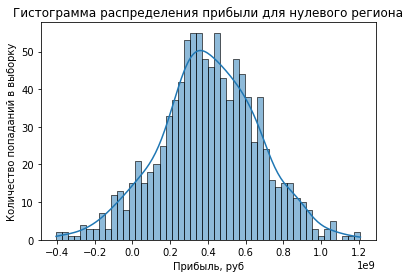

Средняя ожидаемая прибыль нулевого региона 406278783 рублей 

95%-доверительный интервал для нулевого региона от -117742136 до 911737051 рублей

Риск убытков 6.7 процентов


In [ ]:
# считаем для нулевого региона
expectations(X_valid_0, y_valid_0, predictions_0, 'нулевого')

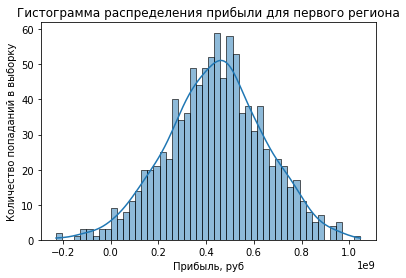

Средняя ожидаемая прибыль первого региона 441504278 рублей 

95%-доверительный интервал для первого региона от 35728489 до 828006639 рублей

Риск убытков 1.6 процентов


In [ ]:
# считаем для первого региона
expectations(X_valid_1, y_valid_1, predictions_1, 'первого')

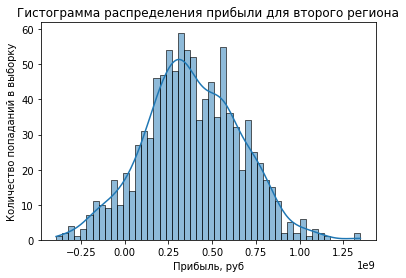

Средняя ожидаемая прибыль второго региона 385213196 рублей 

95%-доверительный интервал для второго региона от -164785166 до 888206234 рублей

Риск убытков 7.8 процентов


In [ ]:
# считаем для второго региона
expectations(X_valid_2, y_valid_2, predictions_2, 'второго')

А вот дальнейшие расчеты и анализ их результатов показали, что первый регион - оптимальный для разработки. Его ожидаемая средняя прибыль даже выше, чем у нулевого, притом первый регион обладает наименьшим из всех процентом рисков, а его доверительный 95% интервал полностью безубыточный!

Худшим из вариантов оказался второй регион: у него наименьшая ожидаемая прибыль, и наибольший из трех месторождений риск убытков.

**Вывод**

Лучшим регионом для добычи является первый, худшим - второй.

## Итоговый вывод

По результатам проведенного исследования, несмотря на наименьшие предсказанные средние запасы сырья лучшим регионом для разработки является первый.
Он имеет максимальную ожидаемую среднюю прибыль, минимальные риски убытков, а 95% доверительный интервал является полностью безубыточным.